# noise_ratio 扫描：50-node ER1 × {noise_ratio=4, 16}

本 notebook 是 `test_calm_paper_table7_repro.ipynb` 的姐妹实验，**唯一改动**：
- `graph_configs` 固定为 `{d: 50, calm_degree: 1.0, graph_type: 'ER'}` (50-node ER1)
- 改为扫描 `noise_ratio ∈ {4, 16}`，分别给出结果表格

其他配置（trials=5、n=20000、不 standardize、7 个算法、所有超参）与 `test_calm_paper_table7_repro.ipynb` 完全一致。

## 1. 环境与导入

In [1]:
import logging
import os
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / 'calm_dataset.py').exists() and (path / 'coordinate_descent').exists():
            return path
    raise RuntimeError(f'Could not find repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate

from MEC import find_v_structures, get_skeleton, is_in_markov_equiv_class
from calm_dataset import CalmDataset, weight_to_binary_adj
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith

print('Python   :', sys.version.split()[0])
print('Repo root:', REPO_ROOT)
print('cd_A          : OK')
print('cd_A_weakfaith: OK')

c:\Users\super\DAG\experiments\notebooks\test
Python   : 3.10.11
Repo root: C:\Users\super\DAG
cd_A          : OK
cd_A_weakfaith: OK


In [2]:
# ── CALM (kaifeng-jin) ────────────────────────────────────────
CALM_REPO_CANDIDATES = [
    Path(os.environ['CALM_REPO']) if os.environ.get('CALM_REPO') else None,
    REPO_ROOT / 'external' / 'CALM',
    REPO_ROOT.parent / 'CALM',
    Path(r'D:\tmp\CALM-inspect'),
]
CALM_REPO = next(
    (p.resolve() for p in CALM_REPO_CANDIDATES
     if p is not None and (p / 'CALM.py').exists()),
    None,
)
CALM_IMPORT_ERROR = None
try:
    if CALM_REPO is None:
        raise FileNotFoundError('CALM repo not found; set $CALM_REPO or clone to external/CALM')
    if str(CALM_REPO) not in sys.path:
        sys.path.insert(0, str(CALM_REPO))
    import torch
    from CALM import calm as calm_algorithm
    HAS_CALM = True
    print(f'CALM      : OK ({CALM_REPO})')
except Exception as exc:
    HAS_CALM = False
    CALM_IMPORT_ERROR = exc
    print(f'CALM unavailable: {exc}')

# ── GOLEM-NV-l1 ───────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = str((REPO_ROOT / 'golemMain' / 'src').resolve())
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as exc:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = exc
    print(f'GOLEM unavailable: {exc}')

# ── NOTEARS (gcastle) ─────────────────────────────────────────
NOTEARS_IMPORT_ERROR = None
_prev_disable = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    from castle.algorithms import Notears as _Notears
    HAS_NOTEARS = True
    print('NOTEARS   : OK')
except Exception as exc:
    HAS_NOTEARS = False
    NOTEARS_IMPORT_ERROR = exc
    print(f'NOTEARS unavailable: {exc}')
finally:
    logging.disable(_prev_disable)

# ── Tetrad: FGES & PC (需要 JDK 21+) ────────────────────────────
TETRAD_IMPORT_ERROR = None
try:
    import fges_compat as _tetrad_mod
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _tetrad_mod.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_TETRAD = True
    print('Tetrad    : OK (FGES + PC available)')
except Exception as exc:
    HAS_TETRAD = False
    TETRAD_IMPORT_ERROR = exc
    print(f'Tetrad unavailable: {exc}')

# ── CPDAG-SHD backend ─────────────────────────────────────────
try:
    _toolbox = str((REPO_ROOT / 'toolbox').resolve())
    if _toolbox not in sys.path:
        sys.path.append(_toolbox)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
    print('CPDAG-SHD : OK (cdt backend)')
except Exception as exc:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print(f'CPDAG-SHD : 使用 fallback ({exc})')

CALM      : OK (D:\tmp\CALM-inspect)


GOLEM     : OK
NOTEARS   : OK
Tetrad    : OK (FGES + PC available)
CPDAG-SHD : 使用 fallback (No module named 'GPUtil')


## 2. 实验配置

**唯一与 `test_calm_paper_table7_repro.ipynb` 不同**：固定 graph 为 50-node ER1，扫描 `noise_ratio ∈ {4, 16}`。

In [ ]:
CFG = {
    # ── 实验规模 ──────────────────────────────────────────
    'trials': 5,
    'seed':   42,

    # ★ 唯一改动：固定 graph 为 50-node ER1，noise_ratio 改为扫描列表
    'graph_config': {'label': '50-node ER1', 'd': 50, 'calm_degree': 1.0, 'graph_type': 'ER'},
    'noise_ratios': [4.0, 8.0, 16.0],

    # 样本量 (统一 20000)
    'n_samples': 20000,

    # ── 数据生成 (CalmDataset) ────────────────────────────
    'sem_type':         'gauss',
    'noise_scale_mode': 'variance',
    'b_scale':          1.0,
    'standardize':      False,          # ★ Table 7: 不 standardize

    # ── CALM ──────────────────────────────────────────────
    'calm_lambda1':         0.005,
    'calm_alpha':           0.01,
    'calm_tau':             0.5,
    'calm_rho_init':        1e-5,
    'calm_rho_mult':        3.0,
    'calm_htol':            1e-8,
    'calm_subproblem_iter': 10000,
    'calm_standardize':     False,
    'calm_device':          'cpu',

    # ── GOLEM-NV-l1 (论文默认) ─────────────────────────────
    'golem_equal_variances': False,
    'golem_lambda1':         2e-3,
    'golem_lambda2':         5.0,
    'golem_num_iter':        10000,
    'golem_learning_rate':   1e-3,
    'golem_threshold':       0.3,

    # ── NOTEARS ───────────────────────────────────────────
    'notears_lambda1':   0.1,
    'notears_loss_type': 'l2',
    'notears_threshold': 0.3,
    # ★ runtime tuning: 默认 h_tol=1e-8 + max_iter=100 在稠密图(noise_ratio=16)上极慢
    'notears_h_tol':     1e-4,          # 1e-8 -> 1e-4 (二值图几乎不变,主要 runtime killer)
    'notears_max_iter':  20,            # 100  -> 20  (兜底 AL 外层 iter)

    # ── PC (Tetrad, FisherZ) ───────────────────────────────
    'pc_alpha':  0.01,
    'pc_stable': True,
    'pc_depth':  -1,

    # ── FGES (Tetrad, SEM-BIC) ─────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── cd_A / cd_A_weakfaith ──────────────────────────────
    # cd_threshold 作用在 cd 学到的权重矩阵 A 上
    # 项目其它实验全部用 0.05 (= coordinate0.py 默认值)，沿用约定
    'cd_T':         500000,
    'cd_threshold': 0.05,
    'cd_lambda_l0': 0.1,
    'wf_tau':       0.05,
    'wf_screening': 'pcorr',
    'wf_combine':   'union',
    'wf_sampling_mode': 'preserve',

    # ── 输出 ──────────────────────────────────────────────
    'out_dir': str((REPO_ROOT / 'experiments' / 'results').resolve()),
    'tag':     'calm_noise_ratio_sweep',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

ALGORITHM_ORDER = [
    'CALM',
    'GOLEM-NV-l1',
    'NOTEARS',
    'PC',
    'FGES',
    'cd_A',
    'cd_A_weakfaith',
]

_gc = CFG['graph_config']
_s0 = int(round(_gc['calm_degree'] * _gc['d']))
print(f"trials       : {CFG['trials']}")
print(f"n_samples    : {CFG['n_samples']}")
print(f"standardize  : {CFG['standardize']}")
print(f"graph        : {_gc['label']}  d={_gc['d']}  s0={_s0} edges")
print(f"noise ratios : {CFG['noise_ratios']}  ({CFG['noise_scale_mode']})")
print('algorithms   :', ALGORITHM_ORDER)

trials       : 5
n_samples    : 20000
standardize  : False
graph        : 50-node ER1  d=50  s0=50 edges
noise ratios : [4.0, 8.0, 16.0]  (variance)
algorithms   : ['CALM', 'GOLEM-NV-l1', 'NOTEARS', 'PC', 'FGES', 'cd_A', 'cd_A_weakfaith']


## 3. 评估函数

In [4]:
def cpdag_shd(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est  = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff    = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def skeleton_precision_recall(G_true: np.ndarray, G_est: np.ndarray):
    skel_true = np.triu(get_skeleton(G_true), k=1).astype(bool)
    skel_est  = np.triu(get_skeleton(G_est),  k=1).astype(bool)
    tp = int(np.sum(skel_true & skel_est))
    fp = int(np.sum((~skel_true) & skel_est))
    fn = int(np.sum(skel_true & (~skel_est)))
    p = tp / (tp + fp) if tp + fp > 0 else 0.0
    r = tp / (tp + fn) if tp + fn > 0 else 0.0
    return float(p), float(r)


def evaluate(G_true: np.ndarray, G_est: np.ndarray) -> dict:
    G_est = np.asarray(G_est, dtype=int).copy()
    np.fill_diagonal(G_est, 0)
    sk_p, sk_r = skeleton_precision_recall(G_true, G_est)
    return {
        'cpdag_shd': cpdag_shd(G_true, G_est),
        'sk_p':      sk_p,
        'sk_r':      sk_r,
        'n_edges_est': int(G_est.sum()),
    }


def tetrad_matrix_to_adj(df_result) -> np.ndarray:
    mat = df_result.values if hasattr(df_result, 'values') else df_result
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def make_dataset(d: int, calm_degree: float, graph_type: str,
                  n: int, seed: int, noise_ratio: float):
    ds = CalmDataset(
        n=n, d=d,
        graph_type=graph_type, degree=calm_degree,
        sem_type=CFG['sem_type'],
        seed=int(seed),
        noise_ratio=noise_ratio,
        noise_scale_mode=CFG['noise_scale_mode'],
        b_scale=CFG['b_scale'],
    )
    G_true = weight_to_binary_adj(ds.B)
    return ds.X, G_true


print('评估函数已就绪。')

评估函数已就绪。


## 4. 算法封装

In [5]:
def _failure(msg) -> dict:
    return {'status': 'failed', 'G_est': None, 'message': str(msg)}


def _sample_cov(X: np.ndarray) -> np.ndarray:
    Xc = X - X.mean(axis=0, keepdims=True)
    return Xc.T @ Xc / Xc.shape[0]


def run_CALM(X, seed):
    if not HAS_CALM:
        return _failure(f'CALM unavailable: {CALM_IMPORT_ERROR}')
    np.random.seed(seed)
    torch.manual_seed(seed)
    B_w = calm_algorithm(
        X,
        lambda1=CFG['calm_lambda1'],
        alpha=CFG['calm_alpha'],
        tau=CFG['calm_tau'],
        rho_init=CFG['calm_rho_init'],
        rho_mult=CFG['calm_rho_mult'],
        htol=CFG['calm_htol'],
        subproblem_iter=CFG['calm_subproblem_iter'],
        standardize=CFG['calm_standardize'],
        device=CFG['calm_device'],
    )
    G_est = (np.abs(np.asarray(B_w)) > 0).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_GOLEM_NV_l1(X, seed):
    if not HAS_GOLEM:
        return _failure(f'GOLEM unavailable: {GOLEM_IMPORT_ERROR}')
    B_est = golem_fit(
        X,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
        num_iter=CFG['golem_num_iter'],
        learning_rate=CFG['golem_learning_rate'],
        seed=int(seed),
    )
    G_est = (np.abs(np.asarray(B_est)) > CFG['golem_threshold']).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_NOTEARS(X, seed):
    if not HAS_NOTEARS:
        return _failure(f'NOTEARS unavailable: {NOTEARS_IMPORT_ERROR}')
    model = _Notears(
        lambda1=CFG['notears_lambda1'],
        loss_type=CFG['notears_loss_type'],
        w_threshold=CFG['notears_threshold'],
        h_tol=CFG['notears_h_tol'],
        max_iter=CFG['notears_max_iter'],
    )
    _prev = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        model.learn(X)
    finally:
        logging.disable(_prev)
    G_est = np.asarray(model.causal_matrix, dtype=int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_PC(X, seed):
    if not HAS_TETRAD:
        return _failure(f'Tetrad unavailable: {TETRAD_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.run_pc(
        alpha=CFG['pc_alpha'],
        stable=CFG['pc_stable'],
        depth=CFG['pc_depth'],
    )
    G_est = tetrad_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_FGES(X, seed):
    if not HAS_TETRAD:
        return _failure(f'Tetrad unavailable: {TETRAD_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
    search.run_fges()
    G_est = tetrad_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A(X, seed):
    S = _sample_cov(X)
    A, G_est, obj = dag_coordinate_descent_l0(
        S=S, T=CFG['cd_T'], seed=int(seed),
        threshold=CFG['cd_threshold'], lambda_l0=CFG['cd_lambda_l0'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A_weakfaith(X, seed):
    S = _sample_cov(X)
    A, G_est, obj = dag_coordinate_descent_l0_weakfaith(
        S=S, T=CFG['cd_T'], seed=int(seed),
        threshold=CFG['cd_threshold'], lambda_l0=CFG['cd_lambda_l0'],
        faithfulness_tau=CFG['wf_tau'],
        screening=CFG['wf_screening'],
        combine=CFG['wf_combine'],
        sampling_mode=CFG['wf_sampling_mode'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


RUNNERS = {
    'CALM':           run_CALM,
    'GOLEM-NV-l1':    run_GOLEM_NV_l1,
    'NOTEARS':        run_NOTEARS,
    'PC':             run_PC,
    'FGES':           run_FGES,
    'cd_A':           run_cd_A,
    'cd_A_weakfaith': run_cd_A_weakfaith,
}
RUNNERS = {k: RUNNERS[k] for k in ALGORITHM_ORDER if k in RUNNERS}
list(RUNNERS)

['CALM', 'GOLEM-NV-l1', 'NOTEARS', 'PC', 'FGES', 'cd_A', 'cd_A_weakfaith']

## 5. 主循环

外层 `noise_ratio × trial × algorithm`，graph 配置固定。

In [6]:
rng = np.random.default_rng(CFG['seed'])
rows = []
skip_logs = []

_gc = CFG['graph_config']
label, d, calm_degree, graph_type = _gc['label'], _gc['d'], _gc['calm_degree'], _gc['graph_type']
n_samples = CFG['n_samples']

for noise_ratio in CFG['noise_ratios']:
    trial_seeds = rng.integers(0, 10**9, size=CFG['trials'])
    for trial_id, data_seed_raw in enumerate(trial_seeds, start=1):
        data_seed = int(data_seed_raw)
        X, G_true = make_dataset(d, calm_degree, graph_type, n_samples, data_seed, noise_ratio)
        n_edges_true = int(G_true.sum())

        for alg_idx, (alg_name, runner) in enumerate(RUNNERS.items()):
            alg_seed = data_seed + 1009 * (alg_idx + 1)
            t0 = time.perf_counter()
            try:
                result = runner(X, alg_seed)
            except Exception as exc:
                result = _failure(exc)
            runtime_sec = time.perf_counter() - t0

            base = {
                'graph_label':  label,
                'd':            d,
                'calm_degree':  calm_degree,
                'noise_ratio':  noise_ratio,
                'n_samples':    n_samples,
                'trial_id':     trial_id,
                'data_seed':    data_seed,
                'algorithm':    alg_name,
                'status':       result['status'],
                'n_edges_true': n_edges_true,
                'runtime_sec':  float(runtime_sec),
                'message':      result.get('message', ''),
            }
            if result['status'] == 'ok':
                metrics = evaluate(G_true, result['G_est'])
                row = {**base, **metrics}
                print(
                    f'[ratio={noise_ratio:>4} | {alg_name:15s}] trial={trial_id} '
                    f"cpdag_shd={row['cpdag_shd']:6.1f} "
                    f"sk_p={row['sk_p']:.3f} sk_r={row['sk_r']:.3f} "
                    f"rt={runtime_sec:6.2f}s"
                )
            else:
                row = {**base, 'cpdag_shd': np.nan, 'sk_p': np.nan,
                       'sk_r': np.nan, 'n_edges_est': np.nan}
                skip_logs.append(base)
                print(f'[SKIP ratio={noise_ratio} | {alg_name}] {result["message"]}')
            rows.append(row)

df_trials = pd.DataFrame(rows)
display(df_trials.head(20))
print(f'\ntotal rows: {len(df_trials)}')

[ratio= 4.0 | CALM           ] trial=1 cpdag_shd=  11.0 sk_p=0.909 sk_r=1.000 rt=1475.30s



2026-05-11 22:15:39,279 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From C:\Users\super\DAG\golemMain\src\models\golem_model.py:71: The name tf.train.AdamOptimizer is deprecated. Please use tf.compat.v1.train.AdamOptimizer instead.

2026-05-11 22:15:39,787 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[ratio= 4.0 | GOLEM-NV-l1    ] trial=1 cpdag_shd=  81.0 sk_p=0.500 sk_r=0.460 rt= 58.95s
[ratio= 4.0 | NOTEARS        ] trial=1 cpdag_shd=   9.0 sk_p=0.958 sk_r=0.920 rt=190.67s
[ratio= 4.0 | PC             ] trial=1 cpdag_shd=   7.0 sk_p=1.000 sk_r=0.980 rt=  6.75s
[ratio= 4.0 | FGES           ] trial=1 cpdag_shd=  18.0 sk_p=0.909 sk_r=1.000 rt=  4.63s
[ratio= 4.0 | cd_A           ] trial=1 cpdag_shd=  54.0 sk_p=0.717 sk_r=0.660 rt=359.45s
[ratio= 4.0 | cd_A_weakfaith ] trial=1 cpdag_shd=   9.0 sk_p=1.000 sk_r=0.900 rt=348.06s
[ratio= 4.0 | CALM           ] trial=2 cpdag_shd=  12.0 sk_p=0.893 sk_r=1.000 rt=2166.67s


2026-05-11 23:07:55,337 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[ratio= 4.0 | GOLEM-NV-l1    ] trial=2 cpdag_shd=  94.0 sk_p=0.529 sk_r=0.360 rt= 75.62s
[ratio= 4.0 | NOTEARS        ] trial=2 cpdag_shd=   5.0 sk_p=0.962 sk_r=1.000 rt=108.37s
[ratio= 4.0 | PC             ] trial=2 cpdag_shd=   2.0 sk_p=0.980 sk_r=1.000 rt=  3.32s
[ratio= 4.0 | FGES           ] trial=2 cpdag_shd=   8.0 sk_p=0.943 sk_r=1.000 rt=  4.25s
[ratio= 4.0 | cd_A           ] trial=2 cpdag_shd=  37.0 sk_p=0.944 sk_r=0.680 rt=312.68s
[ratio= 4.0 | cd_A_weakfaith ] trial=2 cpdag_shd=  31.0 sk_p=1.000 sk_r=0.720 rt=305.61s
[ratio= 4.0 | CALM           ] trial=3 cpdag_shd=   3.0 sk_p=0.962 sk_r=1.000 rt=1185.87s


...

[ratio=16.0 | GOLEM-NV-l1    ] trial=4 cpdag_shd=  93.0 sk_p=0.463 sk_r=0.380 rt= 56.96s
[ratio=16.0 | NOTEARS        ] trial=4 cpdag_shd=  10.0 sk_p=0.942 sk_r=0.980 rt=173.41s
[ratio=16.0 | PC             ] trial=4 cpdag_shd=  11.0 sk_p=1.000 sk_r=1.000 rt=  4.49s
[ratio=16.0 | FGES           ] trial=4 cpdag_shd=  18.0 sk_p=0.926 sk_r=1.000 rt=  4.12s
[ratio=16.0 | cd_A           ] trial=4 cpdag_shd=  39.0 sk_p=0.875 sk_r=0.700 rt=399.38s
[ratio=16.0 | cd_A_weakfaith ] trial=4 cpdag_shd=  24.0 sk_p=1.000 sk_r=0.780 rt=369.51s
[ratio=16.0 | CALM           ] trial=5 cpdag_shd=  40.0 sk_p=0.836 sk_r=0.920 rt=1418.06s


2026-05-12 06:52:05,482 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[ratio=16.0 | GOLEM-NV-l1    ] trial=5 cpdag_shd= 100.0 sk_p=0.426 sk_r=0.520 rt= 62.11s
[ratio=16.0 | NOTEARS        ] trial=5 cpdag_shd=  51.0 sk_p=0.754 sk_r=0.860 rt=490.39s
[ratio=16.0 | PC             ] trial=5 cpdag_shd=  27.0 sk_p=0.979 sk_r=0.940 rt=  4.22s
[ratio=16.0 | FGES           ] trial=5 cpdag_shd=  14.0 sk_p=0.926 sk_r=1.000 rt=  4.36s
[ratio=16.0 | cd_A           ] trial=5 cpdag_shd= 102.0 sk_p=0.561 sk_r=0.640 rt=389.21s
[ratio=16.0 | cd_A_weakfaith ] trial=5 cpdag_shd=  34.0 sk_p=0.875 sk_r=0.840 rt=370.08s


,graph_label,d,calm_degree,noise_ratio,n_samples,trial_id,data_seed,algorithm,status,n_edges_true,runtime_sec,message,cpdag_shd,sk_p,sk_r,n_edges_est
0,50-node ER1,50,1.0,4.0,20000,1,89250953,CALM,ok,50,1475.302063,,11.0,0.909091,1.00,55
1,50-node ER1,50,1.0,4.0,20000,1,89250953,GOLEM-NV-l1,ok,50,58.952495,,81.0,0.500000,0.46,46
2,50-node ER1,50,1.0,4.0,20000,1,89250953,NOTEARS,ok,50,190.665410,,9.0,0.958333,0.92,48
3,50-node ER1,50,1.0,4.0,20000,1,89250953,PC,ok,50,6.748000,,7.0,1.000000,0.98,62
4,50-node ER1,50,1.0,4.0,20000,1,89250953,FGES,ok,50,4.630777,,18.0,0.909091,1.00,68
5,50-node ER1,50,1.0,4.0,20000,1,89250953,cd_A,ok,50,359.445673,,54.0,0.717391,0.66,46
6,50-node ER1,50,1.0,4.0,20000,1,89250953,cd_A_weakfaith,ok,50,348.064795,,9.0,1.000000,0.90,45
7,50-node ER1,50,1.0,4.0,20000,2,773956048,CALM,ok,50,2166.666654,,12.0,0.892857,1.00,56
8,50-node ER1,50,1.0,4.0,20000,2,773956048,GOLEM-NV-l1,ok,50,75.619838,,94.0,0.529412,0.36,34
9,50-node ER1,50,1.0,4.0,20000,2,773956048,NOTEARS,ok,50,108.373232,,5.0,0.961538,1.00,52



total rows: 105


## 6. 汇总：mean ± std

In [7]:
ok = df_trials[df_trials['status'] == 'ok'].copy()
if ok.empty:
    raise RuntimeError('No successful runs.')

df_summary = (
    ok.groupby(['noise_ratio', 'algorithm'], as_index=False)
      .agg(
          trials       = ('trial_id',    'count'),
          cpdag_shd_mean = ('cpdag_shd', 'mean'),
          cpdag_shd_std  = ('cpdag_shd', 'std'),
          sk_p_mean      = ('sk_p',      'mean'),
          sk_p_std       = ('sk_p',      'std'),
          sk_r_mean      = ('sk_r',      'mean'),
          sk_r_std       = ('sk_r',      'std'),
          n_edges_est_mean = ('n_edges_est', 'mean'),
          n_edges_true_mean= ('n_edges_true','mean'),
          runtime_sec_mean = ('runtime_sec', 'mean'),
      )
)
df_summary['algorithm'] = pd.Categorical(df_summary['algorithm'], categories=ALGORITHM_ORDER, ordered=True)
df_summary = df_summary.sort_values(['noise_ratio', 'algorithm']).reset_index(drop=True)
display(df_summary)

_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts}.csv")
_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts}.csv")
df_trials.to_csv(_trials_path, index=False)
df_summary.to_csv(_summary_path, index=False)
print(f'\nsaved trials  -> {_trials_path}')
print(f'saved summary -> {_summary_path}')

,noise_ratio,algorithm,trials,cpdag_shd_mean,cpdag_shd_std,sk_p_mean,sk_p_std,sk_r_mean,sk_r_std,n_edges_est_mean,n_edges_true_mean,runtime_sec_mean
0,4.0,CALM,5,8.2,5.263079,0.933681,0.036445,0.996,0.008944,53.4,50.0,1378.011420
1,4.0,GOLEM-NV-l1,5,93.8,10.034939,0.479809,0.037447,0.432,0.041473,45.4,50.0,59.860667
2,4.0,NOTEARS,5,6.4,6.348228,0.958048,0.052961,0.968,0.036332,50.6,50.0,195.041402
3,4.0,PC,5,12.8,9.230385,0.984157,0.016688,0.980,0.020000,65.0,50.0,4.612518
4,4.0,FGES,5,12.8,4.868265,0.944069,0.028185,1.000,0.000000,65.2,50.0,4.915383
5,4.0,cd_A,5,51.8,11.562872,0.785976,0.111082,0.664,0.016733,42.8,50.0,351.343137
6,4.0,cd_A_weakfaith,5,16.6,9.126883,0.986856,0.019775,0.860,0.081240,43.6,50.0,338.384160
7,8.0,CALM,5,10.8,6.906519,0.918074,0.052470,0.996,0.008944,54.4,50.0,999.928124
8,8.0,GOLEM-NV-l1,5,100.6,14.724130,0.414397,0.098060,0.340,0.104881,41.2,50.0,60.972358
9,8.0,NOTEARS,5,23.4,10.784248,0.867388,0.068007,0.920,0.031623,53.2,50.0,258.683682



saved trials  -> C:\Users\super\DAG\experiments\results\calm_noise_ratio_sweep_trials_20260512_071405.csv
saved summary -> C:\Users\super\DAG\experiments\results\calm_noise_ratio_sweep_summary_20260512_071405.csv


## 7. 论文表格风格 (mean ± std) ：每个 noise_ratio 一张表

In [8]:
def _fmt(mu, sd, p=1):
    if pd.isna(mu):
        return 'n/a'
    if pd.isna(sd):
        sd = 0.0
    return f'{mu:.{p}f} ± {sd:.{p}f}'


tables = {}
for noise_ratio in CFG['noise_ratios']:
    sub = df_summary[df_summary['noise_ratio'] == noise_ratio]
    rows_paper = []
    for alg in ALGORITHM_ORDER:
        s = sub[sub['algorithm'] == alg]
        if s.empty:
            rows_paper.append({
                'algorithm': alg,
                'SHD of CPDAG':         'n/a',
                'Precision of Skeleton': 'n/a',
                'Recall of Skeleton':    'n/a',
            })
            continue
        row = s.iloc[0]
        rows_paper.append({
            'algorithm': alg,
            'SHD of CPDAG':         _fmt(row['cpdag_shd_mean'], row['cpdag_shd_std'], p=1),
            'Precision of Skeleton': _fmt(row['sk_p_mean'],      row['sk_p_std'],      p=2),
            'Recall of Skeleton':    _fmt(row['sk_r_mean'],      row['sk_r_std'],      p=2),
        })
    tbl = pd.DataFrame(rows_paper).set_index('algorithm')
    tables[noise_ratio] = tbl
    print(f"\n=== noise_ratio = {noise_ratio}  ({_gc['label']}, n={CFG['n_samples']}, trials={CFG['trials']}, no standardization) ===")
    display(tbl)

_paper_rows = []
for nr, tbl in tables.items():
    for alg, r in tbl.iterrows():
        _paper_rows.append({'noise_ratio': nr, 'algorithm': alg, **r.to_dict()})
df_paper = pd.DataFrame(_paper_rows)
_paper_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_paper_table_{_ts}.csv")
df_paper.to_csv(_paper_path, index=False)
print(f'\nsaved paper-style table -> {_paper_path}')


=== noise_ratio = 4.0  (50-node ER1, n=20000, trials=5, no standardization) ===


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton
algorithm,,,
CALM,8.2 ± 5.3,0.93 ± 0.04,1.00 ± 0.01
GOLEM-NV-l1,93.8 ± 10.0,0.48 ± 0.04,0.43 ± 0.04
NOTEARS,6.4 ± 6.3,0.96 ± 0.05,0.97 ± 0.04
PC,12.8 ± 9.2,0.98 ± 0.02,0.98 ± 0.02
FGES,12.8 ± 4.9,0.94 ± 0.03,1.00 ± 0.00
cd_A,51.8 ± 11.6,0.79 ± 0.11,0.66 ± 0.02
cd_A_weakfaith,16.6 ± 9.1,0.99 ± 0.02,0.86 ± 0.08



=== noise_ratio = 8.0  (50-node ER1, n=20000, trials=5, no standardization) ===


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton
algorithm,,,
CALM,10.8 ± 6.9,0.92 ± 0.05,1.00 ± 0.01
GOLEM-NV-l1,100.6 ± 14.7,0.41 ± 0.10,0.34 ± 0.10
NOTEARS,23.4 ± 10.8,0.87 ± 0.07,0.92 ± 0.03
PC,13.2 ± 9.8,0.99 ± 0.03,0.98 ± 0.02
FGES,15.4 ± 10.2,0.92 ± 0.01,1.00 ± 0.00
cd_A,56.0 ± 13.3,0.75 ± 0.12,0.66 ± 0.12
cd_A_weakfaith,20.6 ± 4.0,0.97 ± 0.04,0.86 ± 0.05



=== noise_ratio = 16.0  (50-node ER1, n=20000, trials=5, no standardization) ===


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton
algorithm,,,
CALM,18.8 ± 13.8,0.90 ± 0.05,0.97 ± 0.03
GOLEM-NV-l1,100.2 ± 8.8,0.42 ± 0.04,0.39 ± 0.09
NOTEARS,36.0 ± 18.8,0.82 ± 0.08,0.92 ± 0.04
PC,21.4 ± 7.2,0.98 ± 0.02,0.96 ± 0.04
FGES,27.4 ± 25.7,0.92 ± 0.06,1.00 ± 0.00
cd_A,63.0 ± 27.8,0.73 ± 0.12,0.66 ± 0.07
cd_A_weakfaith,24.0 ± 7.9,0.97 ± 0.05,0.81 ± 0.07



saved paper-style table -> C:\Users\super\DAG\experiments\results\calm_noise_ratio_sweep_paper_table_20260512_071405.csv


### 7b. noise_ratio=4 vs 16 并排对比

把两个 noise_ratio 的同一指标合到一张表，方便看 noise 提升带来的退化。

In [9]:
metric_cols = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'SHD of CPDAG',         1),
    ('sk_p_mean',      'sk_p_std',      'Precision of Skeleton', 2),
    ('sk_r_mean',      'sk_r_std',      'Recall of Skeleton',    2),
]
for mcol, scol, title, p in metric_cols:
    out = pd.DataFrame(index=ALGORITHM_ORDER)
    for nr in CFG['noise_ratios']:
        sub = df_summary[df_summary['noise_ratio'] == nr].set_index('algorithm').reindex(ALGORITHM_ORDER)
        out[f'noise_ratio={nr:g}'] = [_fmt(m, s, p=p) for m, s in zip(sub[mcol], sub[scol])]
    print(f'\n=== {title} ===')
    display(out)


=== SHD of CPDAG ===


,noise_ratio=4,noise_ratio=8,noise_ratio=16
CALM,8.2 ± 5.3,10.8 ± 6.9,18.8 ± 13.8
GOLEM-NV-l1,93.8 ± 10.0,100.6 ± 14.7,100.2 ± 8.8
NOTEARS,6.4 ± 6.3,23.4 ± 10.8,36.0 ± 18.8
PC,12.8 ± 9.2,13.2 ± 9.8,21.4 ± 7.2
FGES,12.8 ± 4.9,15.4 ± 10.2,27.4 ± 25.7
cd_A,51.8 ± 11.6,56.0 ± 13.3,63.0 ± 27.8
cd_A_weakfaith,16.6 ± 9.1,20.6 ± 4.0,24.0 ± 7.9



=== Precision of Skeleton ===


,noise_ratio=4,noise_ratio=8,noise_ratio=16
CALM,0.93 ± 0.04,0.92 ± 0.05,0.90 ± 0.05
GOLEM-NV-l1,0.48 ± 0.04,0.41 ± 0.10,0.42 ± 0.04
NOTEARS,0.96 ± 0.05,0.87 ± 0.07,0.82 ± 0.08
PC,0.98 ± 0.02,0.99 ± 0.03,0.98 ± 0.02
FGES,0.94 ± 0.03,0.92 ± 0.01,0.92 ± 0.06
cd_A,0.79 ± 0.11,0.75 ± 0.12,0.73 ± 0.12
cd_A_weakfaith,0.99 ± 0.02,0.97 ± 0.04,0.97 ± 0.05



=== Recall of Skeleton ===


,noise_ratio=4,noise_ratio=8,noise_ratio=16
CALM,1.00 ± 0.01,1.00 ± 0.01,0.97 ± 0.03
GOLEM-NV-l1,0.43 ± 0.04,0.34 ± 0.10,0.39 ± 0.09
NOTEARS,0.97 ± 0.04,0.92 ± 0.03,0.92 ± 0.04
PC,0.98 ± 0.02,0.98 ± 0.02,0.96 ± 0.04
FGES,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
cd_A,0.66 ± 0.02,0.66 ± 0.12,0.66 ± 0.07
cd_A_weakfaith,0.86 ± 0.08,0.86 ± 0.05,0.81 ± 0.07


## 8. 可视化

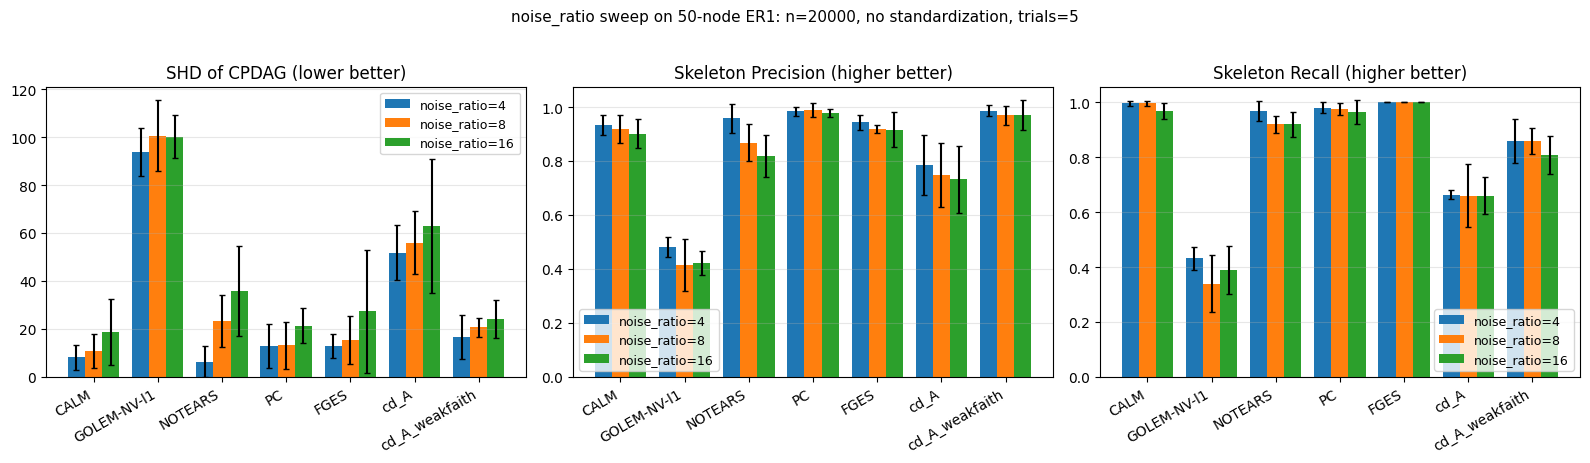

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'SHD of CPDAG (lower better)'),
    ('sk_p_mean',      'sk_p_std',      'Skeleton Precision (higher better)'),
    ('sk_r_mean',      'sk_r_std',      'Skeleton Recall (higher better)'),
]
x_pos = np.arange(len(ALGORITHM_ORDER))
n_groups = len(CFG['noise_ratios'])
width = 0.8 / max(n_groups, 1)

for ax, (mcol, scol, title) in zip(axes, metrics):
    for gi, nr in enumerate(CFG['noise_ratios']):
        sub = df_summary[df_summary['noise_ratio'] == nr].set_index('algorithm').reindex(ALGORITHM_ORDER)
        offset = (gi - (n_groups - 1) / 2) * width
        ax.bar(x_pos + offset, sub[mcol].values, width=width,
               yerr=sub[scol].values, label=f'noise_ratio={nr:g}', capsize=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ALGORITHM_ORDER, rotation=30, ha='right')
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='y')
    ax.legend(fontsize=9)

fig.suptitle(
    f"noise_ratio sweep on {_gc['label']}: "
    f"n={CFG['n_samples']}, no standardization, trials={CFG['trials']}",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## 9. 失败/跳过记录

In [11]:
if skip_logs:
    df_skip = pd.DataFrame(skip_logs)
    display(df_skip)
else:
    print('所有 trial 均运行成功。')

所有 trial 均运行成功。
